In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from epiweeks import Week

import pandas as pd
from epiweeks import Week

d = pd.read_csv("./data/PA_ILI.csv")

d['date'] = d.apply(
    lambda row: Week(row['YEAR'], row['WEEK']).startdate(),
    axis=1
)
d['date'] = pd.to_datetime(d['date'])

d_monthly = (
    d
    .set_index('date')
    .resample('ME')
    .agg({
        'ILITOTAL': 'sum',     # numerator
        'TOTAL PATIENTS': 'sum'  # denominator
    })
    .reset_index()
)

d_monthly['ILI'] = d_monthly['ILITOTAL'] / d_monthly['TOTAL PATIENTS']
print(d_monthly)

          date  ILITOTAL  TOTAL PATIENTS       ILI
0   2010-10-31       754           89557  0.008419
1   2010-11-30       715           66706  0.010719
2   2010-12-31       856           51899  0.016494
3   2011-01-31      2457           76307  0.032199
4   2011-02-28      2426           70710  0.034309
..         ...       ...             ...       ...
181 2025-11-30      6218          383315  0.016222
182 2025-12-31     12069          319156  0.037815
183 2026-01-31      9891          311310  0.031772
184 2026-02-28      7509          320040  0.023463
185 2026-03-31      3622          162640  0.022270

[186 rows x 4 columns]


               Vaccine     Geography  FIPS     Year  Month   Dimension  \
6   Seasonal Influenza  Pennsylvania    42  2010-11      2  >=6 Months   
7   Seasonal Influenza  Pennsylvania    42  2010-11      3  >=6 Months   
8   Seasonal Influenza  Pennsylvania    42  2010-11      4  >=6 Months   
9   Seasonal Influenza  Pennsylvania    42  2010-11      5  >=6 Months   
10  Seasonal Influenza  Pennsylvania    42  2010-11      8  >=6 Months   

    Estimate(%)  New_per_Month  YearNumeric  year  month       Date  
6          42.5            1.5         2010  2010      2 2010-02-01  
7          43.2            0.7         2010  2010      3 2010-03-01  
8          43.4            0.2         2010  2010      4 2010-04-01  
9          43.4            0.0         2010  2010      5 2010-05-01  
10          1.0            1.0         2010  2010      8 2010-08-01  
        date  ILITOTAL  TOTAL PATIENTS       ILI
0 2010-10-31       754           89557  0.008419
1 2010-11-30       715           6670

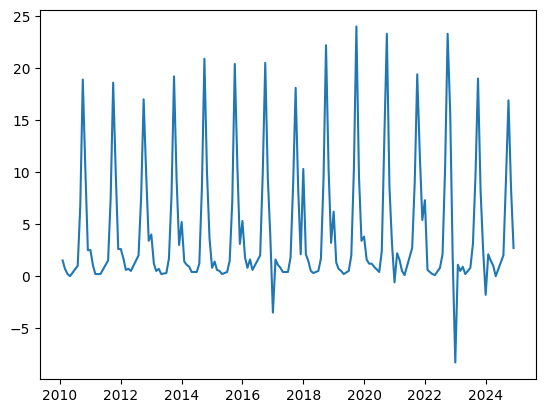

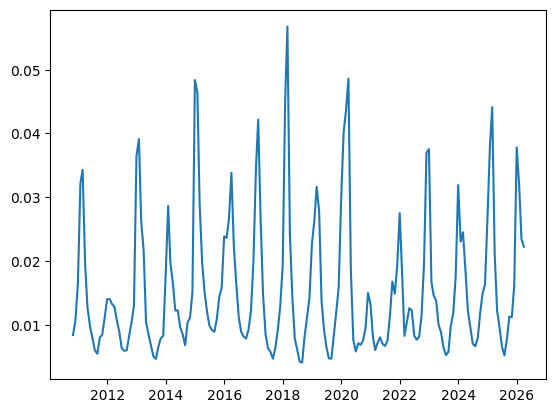

In [12]:

vax = pd.read_csv("./data/Influenza_Vaccination_Coverage_PA.csv")
vax_2010_2025 = vax.loc[6: ] #selects only surveys after 2010
vax_2010_2025.rename(columns={'Season/Survey Year': 'Year'}, inplace=True) 
vax_2010_2025['YearNumeric'] = vax_2010_2025['Year'].str.split('-').str[0].astype(int)
vax_2010_2025['year'] = vax_2010_2025['YearNumeric']
vax_2010_2025['month'] = vax_2010_2025['Month']

vax_2010_2025['Date'] = pd.to_datetime(vax_2010_2025[['year', 'month']].assign(day=1))
print(vax_2010_2025.head())
print(d_monthly.head())
fig, ax = plt.subplots() 
plt.plot (vax_2010_2025["Date"],vax_2010_2025["New_per_Month"])

fig, ax = plt.subplots()
plt.plot (d_monthly['date'], d_monthly['ILI'])

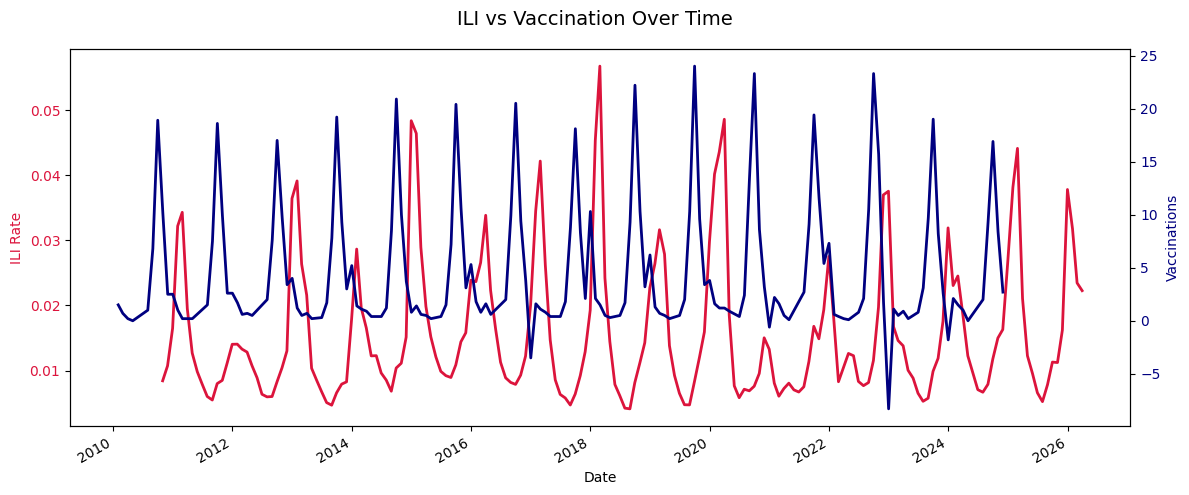

In [18]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(
    d_monthly["date"],
    d_monthly["ILI"],
    color="crimson",
    linewidth=2,
    label="ILI"
)
ax1.set_ylabel("ILI Rate", color="crimson")
ax1.tick_params(axis='y', labelcolor='crimson')

ax2 = ax1.twinx()
ax2.plot(
    vax_2010_2025["Date"],
    vax_2010_2025["New_per_Month"],
    color="navy",
    linewidth=2,
    label="Vaccinations"
)
ax2.set_ylabel("Vaccinations", color="navy")
ax2.tick_params(axis='y', labelcolor='navy')

# --- Formatting ---
ax1.set_xlabel("Date")
fig.suptitle("ILI vs Vaccination Over Time", fontsize=14)

fig.autofmt_xdate()
fig.tight_layout()

plt.show()